# Paso 1. Exploracion de los datos y problema de negocio

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.cluster.hierarchy import fcluster
from sklearn.metrics import silhouette_score

from scipy.stats import (
    shapiro,
    levene,
    mannwhitneyu,
    kruskal
)

df = pd.read_csv("datos_clientes.csv")

df.head()

,Id_Cliente,Genero,Edad,Ingreso,Puntaje_Gasto
0,1,Mujer,41,98115.05,39
1,2,Mujer,20,35458.14,75
2,3,Mujer,68,59872.08,55
3,4,Hombre,63,48508.93,51
4,5,Mujer,31,44431.11,54


In [ ]:
#Inspección

print("Dimensiones:", df.shape)

print("\nTipos de variables:")
print(df.dtypes)

print("\nValores faltantes:")
print(df.isna().sum())

print("\nDuplicados:")
print(df.duplicated().sum())

print("\nNúmero de clientes únicos:")
print(df["Id_Cliente"].nunique())

Dimensiones: (200, 5)

Tipos de variables:
Id_Cliente         int64
Genero               str
Edad               int64
Ingreso          float64
Puntaje_Gasto      int64
dtype: object

Valores faltantes:
Id_Cliente       0
Genero           0
Edad             0
Ingreso          0
Puntaje_Gasto    0
dtype: int64

Duplicados:
0

Número de clientes únicos:
200


La base contiene 200 registros correspondientes a 200 clientes distintos. No se identifican valores faltantes ni observaciones duplicadas, por lo que no se requiere tratamiento de datos incompletos en esta etapa. Id_Cliente funciona exclusivamente como identificador y no debe utilizarse como variable de clustering, porque su valor numérico no representa similitud entre clientes.

In [ ]:
#Estadistica descriptiva

df.describe()

,Id_Cliente,Edad,Ingreso,Puntaje_Gasto
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60624.446600,50.200000
std,57.879185,13.969007,26262.903416,25.823522
min,1.000000,18.000000,13458.020000,1.000000
25%,50.750000,28.750000,41512.787500,34.750000
50%,100.500000,36.000000,60777.960000,50.000000
75%,150.250000,49.000000,77143.865000,73.000000
max,200.000000,70.000000,138584.520000,99.000000


In [ ]:
df["Genero"].value_counts()

Genero
Mujer     112
Hombre     88
Name: count, dtype: int64

La muestra presenta amplitud considerable tanto en ingreso como en comportamiento de gasto. El ingreso varía aproximadamente entre 13.500 y 138.600, mientras que el puntaje de gasto cubre prácticamente toda su escala disponible, de 1 a 99. Esto sugiere heterogeneidad suficiente para investigar si existen perfiles diferenciados de clientes.

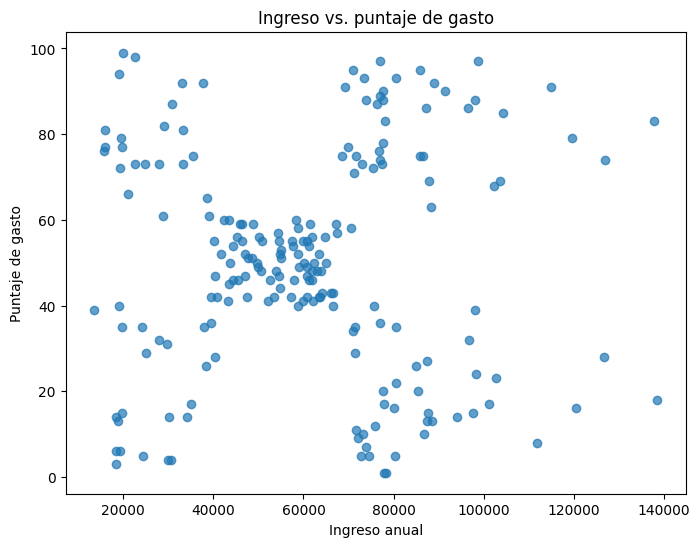

In [ ]:
#Ingreso vs. puntaje de gastos

plt.figure(figsize=(8, 6))

plt.scatter(
    df["Ingreso"],
    df["Puntaje_Gasto"],
    alpha=0.7
)

plt.xlabel("Ingreso anual")
plt.ylabel("Puntaje de gasto")
plt.title("Ingreso vs. puntaje de gasto")

plt.show()

La dispersión ingreso–puntaje de gasto sugiere visualmente la presencia de varias regiones de concentración. Sin embargo, la cantidad exacta de grupos no resulta inequívoca únicamente por inspección visual. Este gráfico se utiliza como evidencia exploratoria y no como criterio definitivo para fijar el número de clusters.

In [ ]:
#Revisar correlaciones antes de segmentar
corr = df[
    ["Edad", "Ingreso", "Puntaje_Gasto"]
].corr()

corr

,Edad,Ingreso,Puntaje_Gasto
Edad,1.000000,-0.007701,-0.327227
Ingreso,-0.007701,1.000000,0.008821
Puntaje_Gasto,-0.327227,0.008821,1.000000


La ausencia de correlación lineal entre ingreso y gasto no implica ausencia de segmentación. De hecho, una población compuesta por perfiles opuestos puede producir una correlación global cercana a cero aun cuando existan agrupamientos bien diferenciados localmente.

In [ ]:
#Comparar hombres y mujeres
resumen_genero = (
    df.groupby("Genero")
    [["Ingreso", "Puntaje_Gasto"]]
    .agg(["count", "mean", "median", "std"])
)

resumen_genero

Ingreso                                        Puntaje_Gasto  \
         count          mean     median           std         count   
Genero                                                                
Hombre      88  62126.660455  61706.565  26765.492953            88   
Mujer      112  59444.135714  59355.305  25920.459216           112   

                                    
             mean median       std  
Genero                              
Hombre  48.511364   50.0  27.89677  
Mujer   51.526786   50.0  24.11495

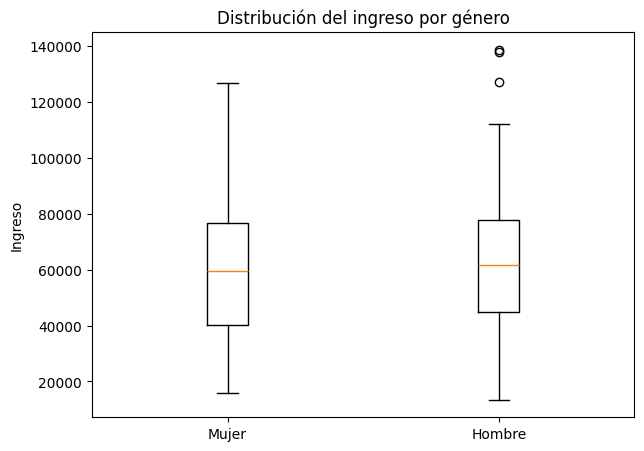

In [ ]:
#Visualizar
fig, ax = plt.subplots(figsize=(7, 5))

datos = [
    df.loc[df["Genero"] == "Mujer", "Ingreso"],
    df.loc[df["Genero"] == "Hombre", "Ingreso"]
]

ax.boxplot(
    datos,
    tick_labels=["Mujer", "Hombre"]
)

ax.set_ylabel("Ingreso")
ax.set_title("Distribución del ingreso por género")

plt.show()

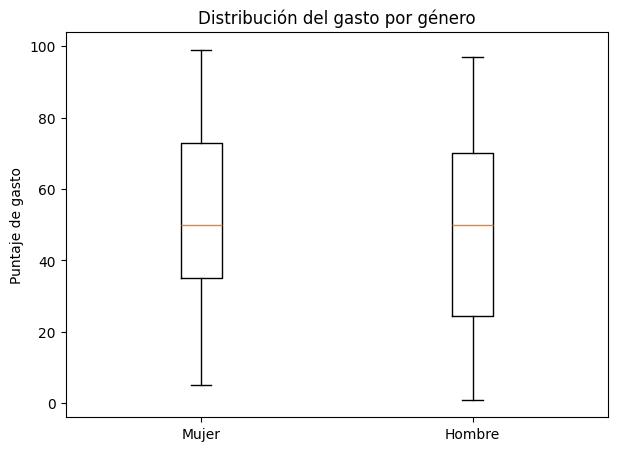

In [ ]:
#Puntaje
fig, ax = plt.subplots(figsize=(7, 5))

datos = [
    df.loc[df["Genero"] == "Mujer", "Puntaje_Gasto"],
    df.loc[df["Genero"] == "Hombre", "Puntaje_Gasto"]
]

ax.boxplot(
    datos,
    tick_labels=["Mujer", "Hombre"]
)

ax.set_ylabel("Puntaje de gasto")
ax.set_title("Distribución del gasto por género")

plt.show()

In [ ]:
#Revisar normalidad
for variable in ["Ingreso", "Puntaje_Gasto"]:

    print(f"\n{variable}")

    for genero in df["Genero"].unique():

        datos = df.loc[
            df["Genero"] == genero,
            variable
        ]

        stat, p = shapiro(datos)

        print(
            genero,
            "p-value Shapiro:",
            round(p, 4)
        )


Ingreso
Mujer p-value Shapiro: 0.048
Hombre p-value Shapiro: 0.0489

Puntaje_Gasto
Mujer p-value Shapiro: 0.0298
Hombre p-value Shapiro: 0.0026


In [ ]:
#Mann-whitney no exige normalidad, vale la pena revisar
for variable in ["Ingreso", "Puntaje_Gasto"]:

    hombres = df.loc[
        df["Genero"] == "Hombre",
        variable
    ]

    mujeres = df.loc[
        df["Genero"] == "Mujer",
        variable
    ]

    stat, p = mannwhitneyu(
        hombres,
        mujeres,
        alternative="two-sided"
    )

    print(
        variable,
        "p-value:",
        round(p, 4)
    )

Ingreso p-value: 0.461
Puntaje_Gasto p-value: 0.5713


Aunque hombres y mujeres presentan pequeñas diferencias en sus medias, las pruebas de Mann–Whitney no muestran evidencia estadísticamente significativa de diferencias en ingreso ni puntaje de gasto al nivel \(\alpha=0.05\). Por ello, en esta muestra el género no parece constituir por sí solo una dimensión conductual fuerte para focalizar la campaña.

In [ ]:
#Ahora entre grupos etarios

bins = [
    18,
    25,
    35,
    45,
    55,
    65,
    np.inf
]

labels = [
    "18-24",
    "25-34",
    "35-44",
    "45-54",
    "55-64",
    "65+"
]

df["Grupo_Etario"] = pd.cut(
    df["Edad"],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True
)

df["Grupo_Etario"].value_counts().sort_index()

Grupo_Etario
18-24    35
25-34    54
35-44    42
45-54    39
55-64    16
65+      14
Name: count, dtype: int64

In [ ]:
#Rsumen estadistico por edad
resumen_edad = (
    df.groupby(
        "Grupo_Etario",
        observed=False
    )
    [["Ingreso", "Puntaje_Gasto"]]
    .agg(["count", "mean", "median", "std"])
)

resumen_edad

Ingreso                                        Puntaje_Gasto  \
               count          mean     median           std         count   
Grupo_Etario                                                                
18-24             35  44454.795429  46455.340  20378.208373            35   
25-34             54  71157.328148  75824.910  27885.788157            54   
35-44             42  66957.096905  71638.860  27722.049259            42   
45-54             39  58786.491026  55041.390  24276.268114            39   
55-64             16  56357.093125  54718.180  22351.828240            16   
65+               14  51420.789286  51546.645  12686.437083            14   

                                           
                   mean median        std  
Grupo_Etario                               
18-24         56.257143   55.0  24.659258  
25-34         63.166667   70.0  24.283506  
35-44         49.428571   41.0  30.700078  
45-54         36.230769   42.0  16.261776  
55-64         32.312500   39.0  21.752299  
65+           46.714286   49.0  11.431593

In [ ]:
#Prueba estadistica entre grupos etarios
for variable in ["Ingreso", "Puntaje_Gasto"]:

    grupos = [
        grupo[variable].values
        for _, grupo in df.groupby(
            "Grupo_Etario",
            observed=False
        )
    ]

    stat, p = kruskal(*grupos)

    print(
        variable,
        "p-value:",
        p
    )

Ingreso p-value: 2.7513407092153548e-05
Puntaje_Gasto p-value: 1.2894171615973073e-06


Conclusiones de la exploración

La base contiene 200 clientes sin registros faltantes ni duplicados. El ingreso y el puntaje de gasto presentan una dispersión amplia y la visualización conjunta sugiere regiones diferenciadas de comportamiento, aunque la cantidad exacta de segmentos no puede establecerse únicamente por inspección visual.

El género no presenta evidencia estadísticamente significativa de diferencias en ingreso ni puntaje de gasto (p > 0.05 en Mann–Whitney), por lo que no parece aportar inicialmente una separación conductual clara para la campaña.

En contraste, los grupos etarios muestran diferencias estadísticamente significativas tanto en ingreso como en puntaje de gasto (p < 0.001 en Kruskal–Wallis). Los clientes entre 25–34 años presentan, descriptivamente, los mayores niveles medios de gasto, mientras que los grupos 45–64 muestran niveles menores.

Estos resultados no definen todavía los clusters. Su función es identificar estructura potencial y orientar las siguientes decisiones de modelamiento. El número de segmentos deberá determinarse posteriormente a partir de clustering jerárquico, dendrogramas, silueta y análisis de sensibilidad, sin confundir el número de grupos existentes con las dos campañas que el cliente puede financiar.

# Paso 2. Clustering Jerarquico

### 2.1 Clustering Jeraquico con enlace WARD + Variables estandarizadas.
El primer algoritmo que vamos a desarrollar es un clustering jerarquico con el enlace ward utilizando las variables de ingreso y puntaje de gasto estandarizadas. La matriz de distancia que definimos es la distancia euclidiana.

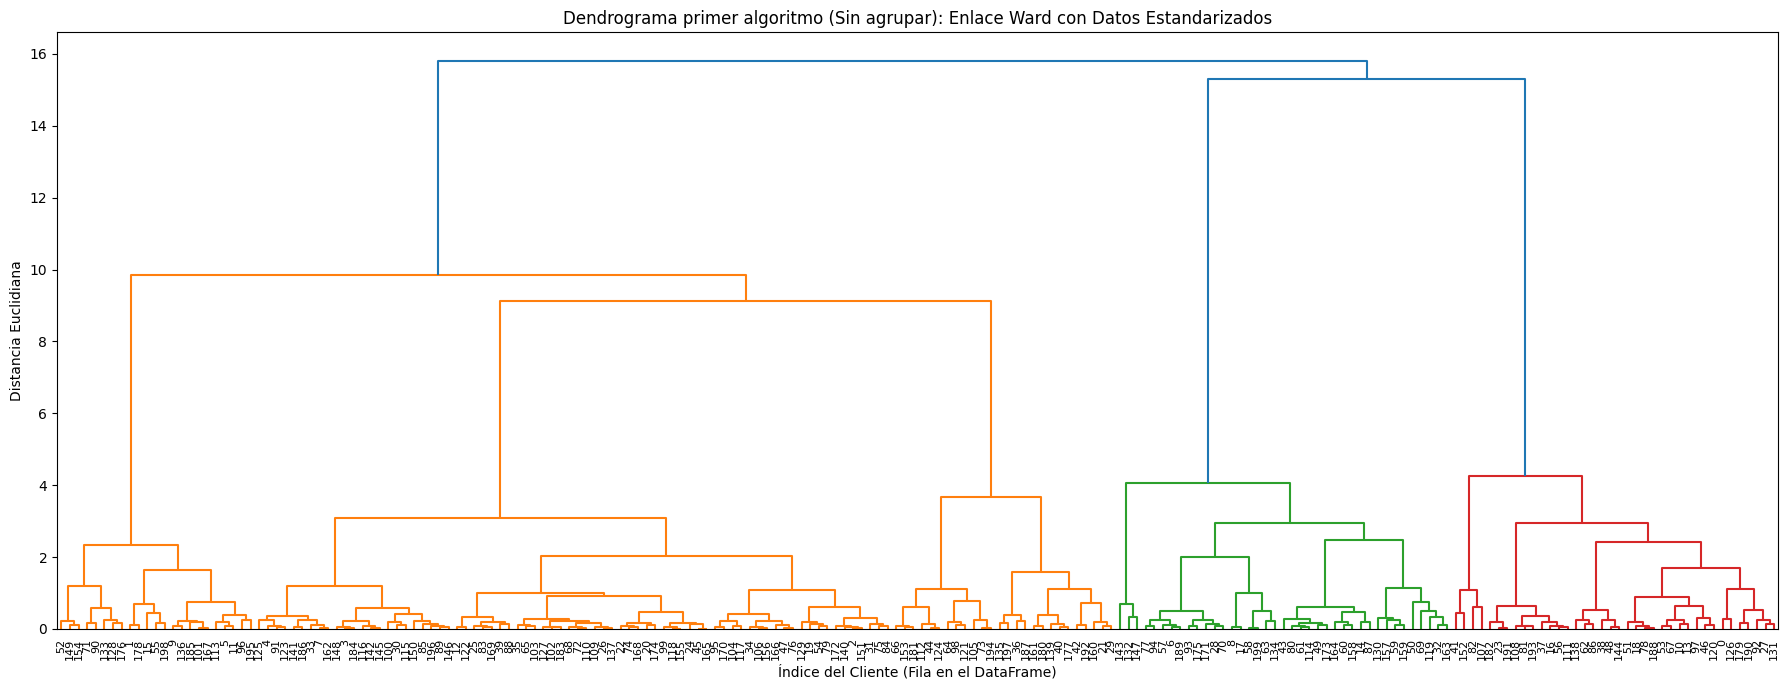

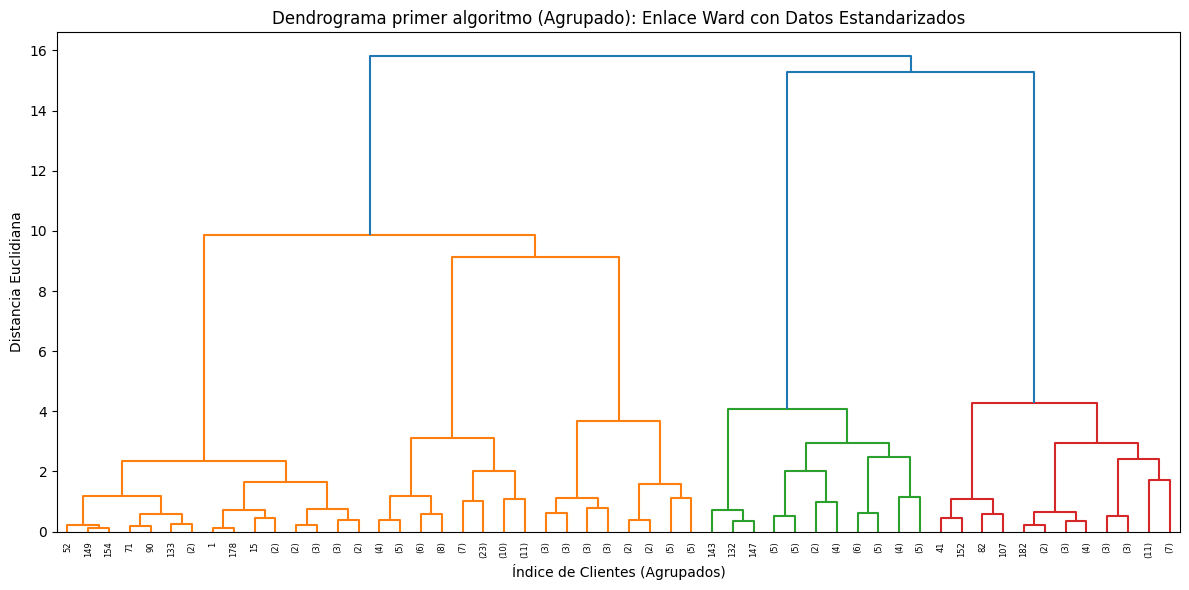

In [ ]:
# 1. Seleccionar exclusivamente las dos variables
X = df[['Ingreso', 'Puntaje_Gasto']]

# 2. Estandarizar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Calcular explícitamente la matriz de distancias euclidianas
distancias_euclidianas = pdist(X_scaled, metric='euclidean')

# 4. Clustering jerárquico usando el enlace de Ward
Z_ward_scaled = linkage(distancias_euclidianas, method='ward')

# 5. Graficar el dendrograma
plt.figure(figsize=(18, 7))
plt.title('Dendrograma primer algoritmo (Sin agrupar): Enlace Ward con Datos Estandarizados')
plt.xlabel('Índice del Cliente (Fila en el DataFrame)')
plt.ylabel('Distancia Euclidiana')

# Dendograma completo
dendrogram(Z_ward_scaled,
           leaf_rotation=90.,
           leaf_font_size=8.)

plt.tight_layout()
plt.show()

# Dendograma agrupado
plt.figure(figsize=(12, 6))
plt.title('Dendrograma primer algoritmo (Agrupado): Enlace Ward con Datos Estandarizados')
plt.xlabel('Índice de Clientes (Agrupados)')
plt.ylabel('Distancia Euclidiana')

dendrogram(Z_ward_scaled, truncate_mode='level', p=5, show_leaf_counts=True)

plt.tight_layout()
plt.show()



Ejecutando el algoritmo y visualizando el dendograma obtuvimos las siguientes conclusiones:

1.  Al aplicar la estandarización previa, garantizamos que el Ingreso (con valores en miles) y el Puntaje_Gasto (de 1 a 99) tuvieran exactamente el mismo peso al calcular las distancias euclidianas. Sobre este espacio equilibrado, el enlace de Ward actuó buscando minimizar la varianza interna de los grupos en cada paso. Dado que Ward penaliza fuertemente las uniones de puntos dispersos, el algoritmo favoreció la creación de clústeres compactos.

2. La estructura revelada por el dendrograma:
El eje vertical del gráfico representa la distancia máxima euclidiana entre los clústeres al unirse; la informacion que nos muestra el dendograma nos indica lo siguiente:

- En la parte inferior, las uniones ocurren a distancias muy pequeñas entre 0 y 4, lo que indica que hay muchos clientes con perfiles de ingreso y gasto extremadamente similares.

- En la parte superior las líneas verticales más largas se extienden ininterrumpidamente aproximadamente desde la distancia 10 hasta la 15. Esto nos indica que existen cinco perfiles de consumidores radicalmente distintos, lo que hace inviable cualquier estrategia comercial masiva. Esta marcada separación estructural sobresalta el riesgo de caer en la circularidad analítica: forzar al algoritmo a encontrar solo dos grupos de clientes para encajar en el presupuesto disponible mezclaría hábitos de compra opuestos y diluiría el impacto del mensaje. En su lugar, la geometría de los datos otorga una alta certidumbre para afirmar que el mercado se divide naturalmente en cinco nichos muy sólidos, permitiendo que la elección de los dos tipos de clientes a financiar deje de ser una decision matematica y se convierta en una decisión puramente estratégica.

- Si trazamos un corte horizontal en la distancia de 12, tendriamos exactamente 4 grupos de clientes. Si intentáramos agrupar a los clientes en solo 2 grupos de clústeres (subiendo el punto de corte por encima de 16), el algoritmo nos cobraría una penalización enorme en la varianza, mezclando perfiles de clientes que en realidad son muy distintos.

3.  La estructura intrínseca de los datos establece de forma contundente que existen 5 segmentos naturales de clientes. Forzar al algoritmo a encontrar solo 2 grupos desde el principio habría destruido la estructura real de los datos y ocultado nichos de mercado importantes.

4. Ahora que estadisticamente el dendograma nos entregó 5 clústeres bien definidos, la decisión de qué 2 segmentos financiará la campaña se convierte en una decisión estratégica, no algorítmica.


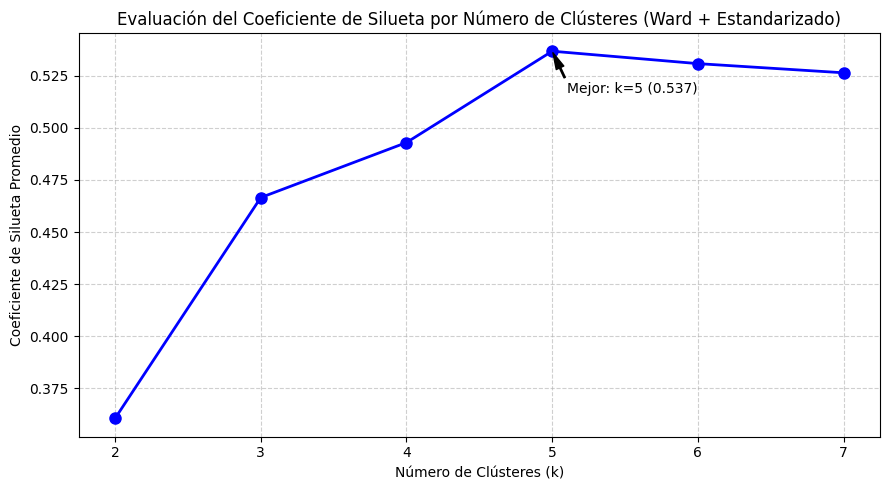

In [ ]:

# 1. Definir el rango de clústeres a evaluar
rango_clusters = range(2, 8)
valores_silueta = []

for k in rango_clusters:
    labels = fcluster(Z_ward_scaled, t=k, criterion='maxclust')
    score = silhouette_score(X_scaled, labels)
    valores_silueta.append(score)

# 2. Graficar los resultados
plt.figure(figsize=(9, 5))
plt.plot(rango_clusters, valores_silueta, marker='o', linestyle='-', color='b', linewidth=2, markersize=8)
plt.title('Evaluación del Coeficiente de Silueta por Número de Clústeres (Ward + Estandarizado)')
plt.xlabel('Número de Clústeres (k)')
plt.ylabel('Coeficiente de Silueta Promedio')
plt.grid(True, linestyle='--', alpha=0.6)

max_silueta = max(valores_silueta)
mejor_k = rango_clusters[valores_silueta.index(max_silueta)]
plt.annotate(f'Mejor: k={mejor_k} ({max_silueta:.3f})',
             xy=(mejor_k, max_silueta),
             xytext=(mejor_k + 0.1, max_silueta - 0.02),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))

plt.tight_layout()
plt.show()

La evaluación del coeficiente de silueta ratifica de forma contundente y científica la lectura geométrica del dendrograma, alcanzando su pico máximo exactamente en $k = 5$ con un valor superior a $0.537$. Este punto óptimo demuestra que la división del mercado en cinco nichos no se define unicamente de manera visual, sino que es una estructura real donde la cohesión interna y la separación entre grupos alcanzan su mejor equilibrio. En contraste, la caída abrupta del puntaje al reducir los clústeres tres o dos nos confirma que forzar agrupaciones menores penaliza la calidad y destruye la heterogeneidad de los datos. De este modo, la convergencia entre el dendrograma y la métrica de silueta valida con absoluta solidez analítica la existencia de cinco segmentos bien definidos, respaldando que la selección posterior de las dos campañas prioritarias sea una decisión estrictamente estratégica y no un sesgo del algoritmo.

### 2.2 Clustering Jeraquico con enlace COMPLETO + Variables estandarizadas.
El segundo algoritmo que vamos a desarrollar es un clustering jerarquico con el enlace COMPLETO utilizando las variables de ingreso y puntaje de gasto estandarizadas. La matriz de distancia que definimos es la distancia euclidiana para tener similitud en los resultados con el primer algoritmo ya que el enlace WARD solo permite ese tipo de matriz.

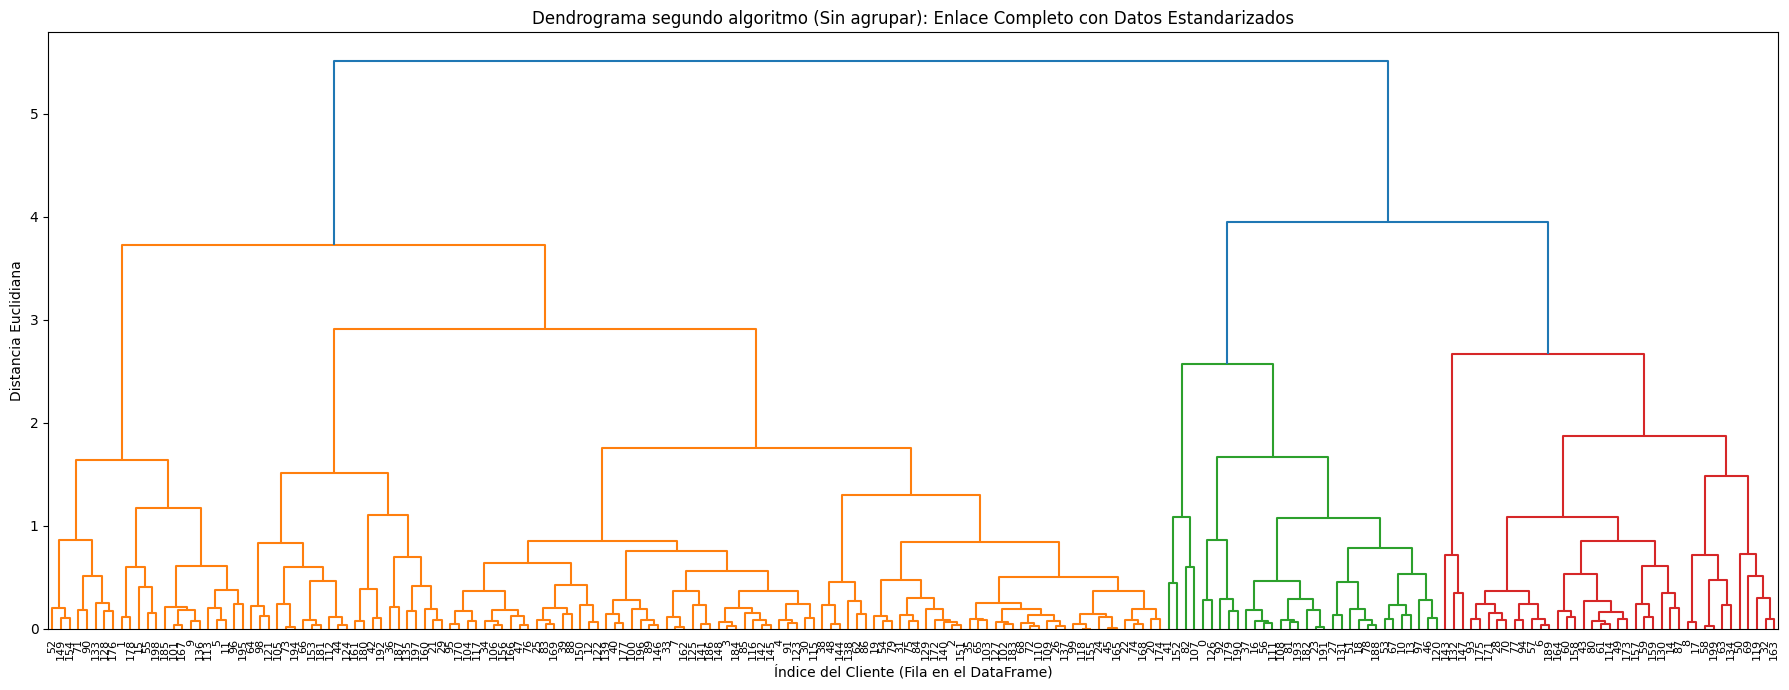

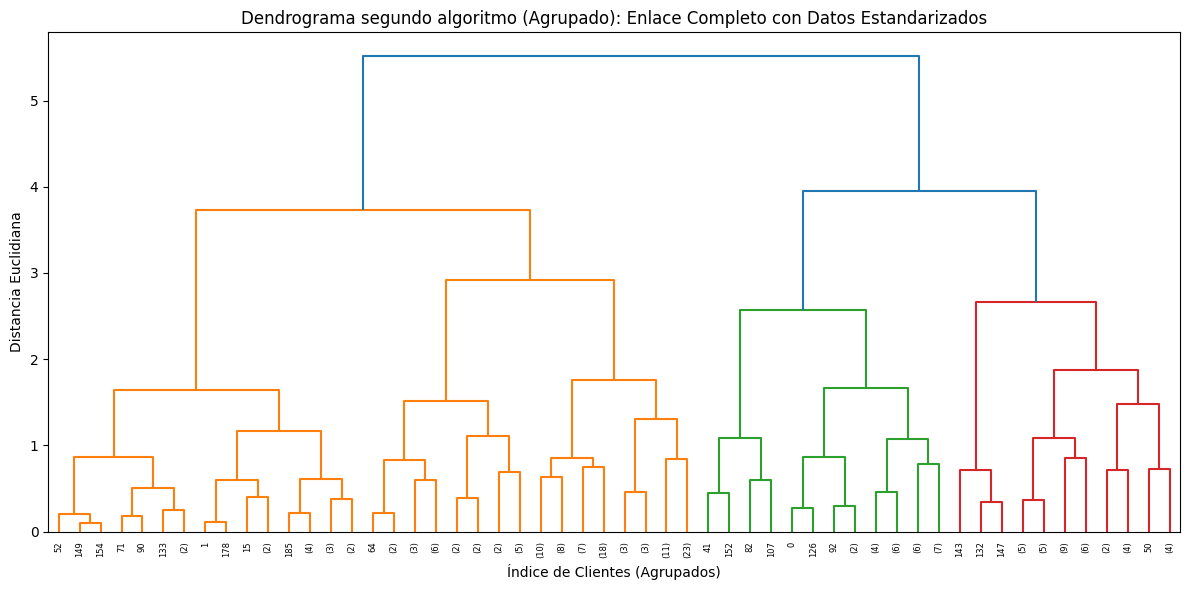

In [ ]:
# 1. Seleccionar exclusivamente las dos variables
X = df[['Ingreso', 'Puntaje_Gasto']]

# 2. Estandarizar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Calculo de la matriz de distancias euclidianas
distancias_euclidianas = pdist(X_scaled, metric='euclidean')

# 4. Clustering jerárquico usando el enlace de Completo
Z_complete_scaled = linkage(distancias_euclidianas, method='complete')

# 5. Graficar el dendrograma
plt.figure(figsize=(18, 7))
plt.title('Dendrograma segundo algoritmo (Sin agrupar): Enlace Completo con Datos Estandarizados')
plt.xlabel('Índice del Cliente (Fila en el DataFrame)')
plt.ylabel('Distancia Euclidiana')

# Dendograma completo
dendrogram(Z_complete_scaled,
           leaf_rotation=90.,
           leaf_font_size=8.)

plt.tight_layout()
plt.show()

# Dendograma agrupado
plt.figure(figsize=(12, 6))
plt.title('Dendrograma segundo algoritmo (Agrupado): Enlace Completo con Datos Estandarizados')
plt.xlabel('Índice de Clientes (Agrupados)')
plt.ylabel('Distancia Euclidiana')

dendrogram(Z_complete_scaled, truncate_mode='level', p=5, show_leaf_counts=True)

plt.tight_layout()
plt.show()


Ejecutando el algoritmo y visualizando el dendograma obtuvimos las siguientes conclusiones:
1. Al aplicar la estandarización previa, garantizamos que el Ingreso (con valores en miles) y el Puntaje_Gasto (de 1 a 99) tuvieran exactamente el mismo peso al calcular las distancias euclidianas. Sobre este espacio equilibrado, el enlace completo actuó midiendo la distancia máxima (el punto más lejano) entre los pares de elementos de diferentes grupos en cada paso. Dado que el enlace completo prioriza la densidad evaluando los límites más distantes de los clústeres, el algoritmo favoreció la creación de agrupaciones estrictamente delimitadas.

2. La estructura revelada por el dendrograma:
El eje vertical del gráfico representa la distancia máxima euclidiana entre los clústeres al unirse; la información que nos muestra el dendrograma nos indica lo siguiente:

- En la parte inferior, las uniones ocurren a distancias muy pequeñas (entre 0 y 1.5), lo que indica que hay muchos clientes con perfiles de ingreso y gasto extremadamente similares y compactos.

- En la parte superior, las líneas verticales más largas se extienden ininterrumpidamente aproximadamente desde la distancia 2.8 hasta la 3.7 (y un gran salto final cerca de 5.5). Esto nos indica que existen varios perfiles de consumidores bien diferenciados, lo que hace inviable cualquier estrategia comercial masiva. Esta marcada separación estructural resalta el riesgo de caer en la circularidad analítica: forzar al algoritmo a encontrar solo dos grupos de clientes para encajar en el presupuesto disponible mezclaría hábitos de compra opuestos y diluiría el impacto del mensaje. En su lugar, la geometría de los datos otorga una alta certidumbre para afirmar que el mercado se divide naturalmente subgrupos muy sólidos, permitiendo que la elección de los dos tipos de clientes a financiar deje de ser una decision matematica y se convierta en una decisión puramente estratégica.

- Si trazamos un corte horizontal en la distancia de 3.8, obtendríamos las ramas principales de la estructura que serian 4. Forzar agrupaciones arbitrarias muy altas o muy bajas sin atender a los saltos naturales del enlace completo penalizaría la cohesión de los grupos, mezclando perfiles de clientes que en realidad responden a dinámicas distintas.

3. La estructura intrínseca de los datos evaluada bajo esta nueva óptica matemática permite contrastar la robustez del modelo. A diferencia de Ward (que minimiza varianzas internas), el enlace completo evalúa el diámetro máximo de los grupos, lo que nos ayuda a comprobar si los conglomerados se mantienen estables frente a distintas tecnicas de aglomeración.

4. Ahora que estadísticamente el dendrograma nos entrega una visualizacion de los posibles cortes óptimos definidos por el enlace completo, la decisión de qué segmentos financiará la campaña se consolida como una decisión estratégica y no algorítmica.

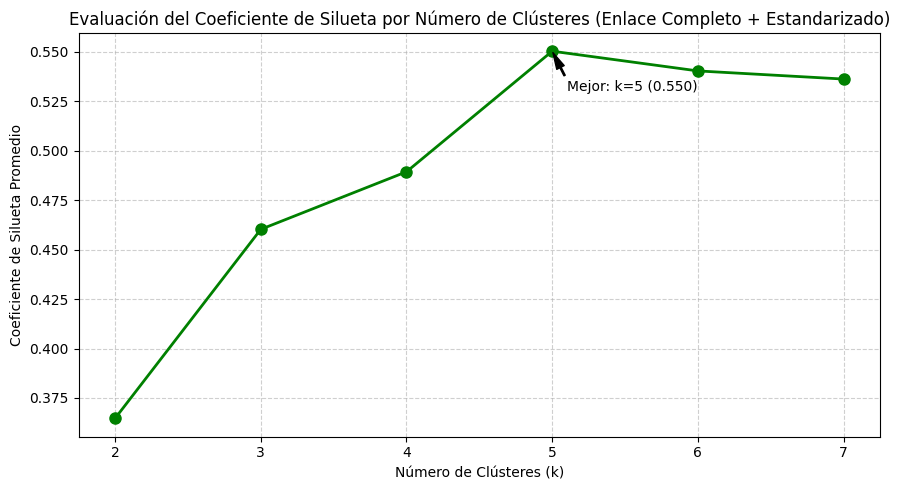

In [ ]:
# 1. Definir el rango de clústeres a evaluar
rango_clusters = range(2, 8)
valores_silueta = []

for k in rango_clusters:
    # Cortar el árbol usando el enlace COMPLETO para k clústeres
    labels = fcluster(Z_complete_scaled, t=k, criterion='maxclust')
    # Calcular silueta
    score = silhouette_score(X_scaled, labels)
    valores_silueta.append(score)

# 2. Graficar los resultados
plt.figure(figsize=(9, 5))
plt.plot(rango_clusters, valores_silueta, marker='o', linestyle='-', color='g', linewidth=2, markersize=8)
plt.title('Evaluación del Coeficiente de Silueta por Número de Clústeres (Enlace Completo + Estandarizado)')
plt.xlabel('Número de Clústeres (k)')
plt.ylabel('Coeficiente de Silueta Promedio')
plt.grid(True, linestyle='--', alpha=0.6)

# Destacar el punto con mayor silueta
max_silueta = max(valores_silueta)
mejor_k = rango_clusters[valores_silueta.index(max_silueta)]
plt.annotate(f'Mejor: k={mejor_k} ({max_silueta:.3f})',
             xy=(mejor_k, max_silueta),
             xytext=(mejor_k + 0.1, max_silueta - 0.02),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))

plt.tight_layout()
plt.show()

La evaluación del coeficiente de silueta para el enlace completo ratifica cuantitativamente los hallazgos del dendrograma al alcanzar su pico máximo exactamente en $k = 5$ con un sobresaliente puntaje de $0.550$, demostrando que esta partición maximiza la cohesión interna y la separación de los datos. Esta métrica confirma que forzar agrupaciones menores (como cuatro o tres clústeres) penaliza la calidad analítica y destruye la heterogeneidad de los perfiles. Al converger con los resultados previos del método de Ward, se comprueba la absoluta robustez estructural de los conglomerados frente a las distintas tecnicas de aglomeración, eliminando sesgos algorítmicos y asegurando que la elección de las campañas prioritarias repose sobre cinco nichos de mercado sólidamente validados.

### 2.3 Clustering Jeraquico con enlace WARD + Variables sin estandarizar.

El tercer algoritmo que vamos a desarrollar es un clustering jerarquico con el enlace ward utilizando las variables de ingreso y puntaje de gasto sin estandarizar. La matriz de distancia que definimos es la distancia euclidiana.

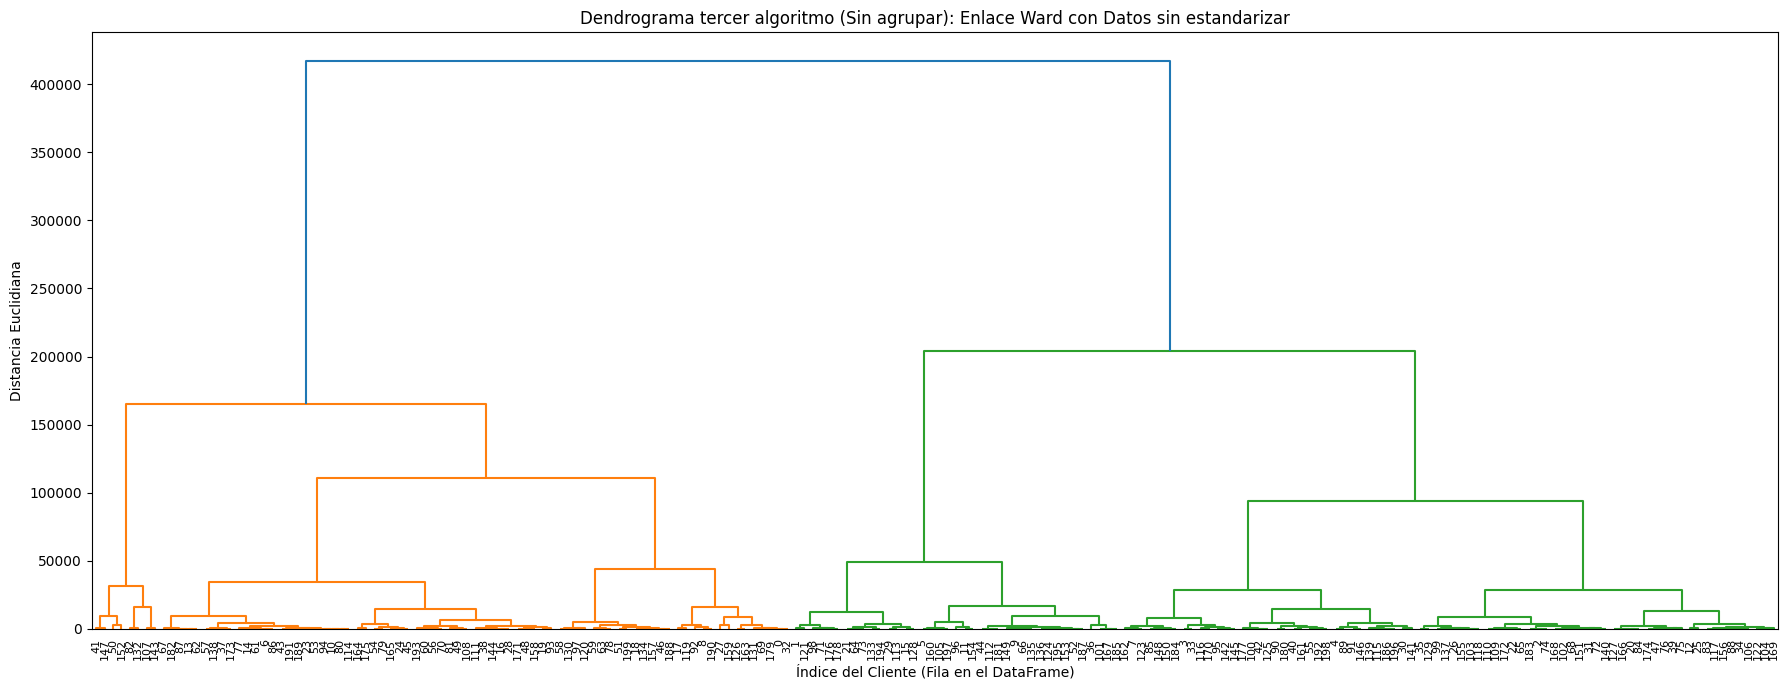

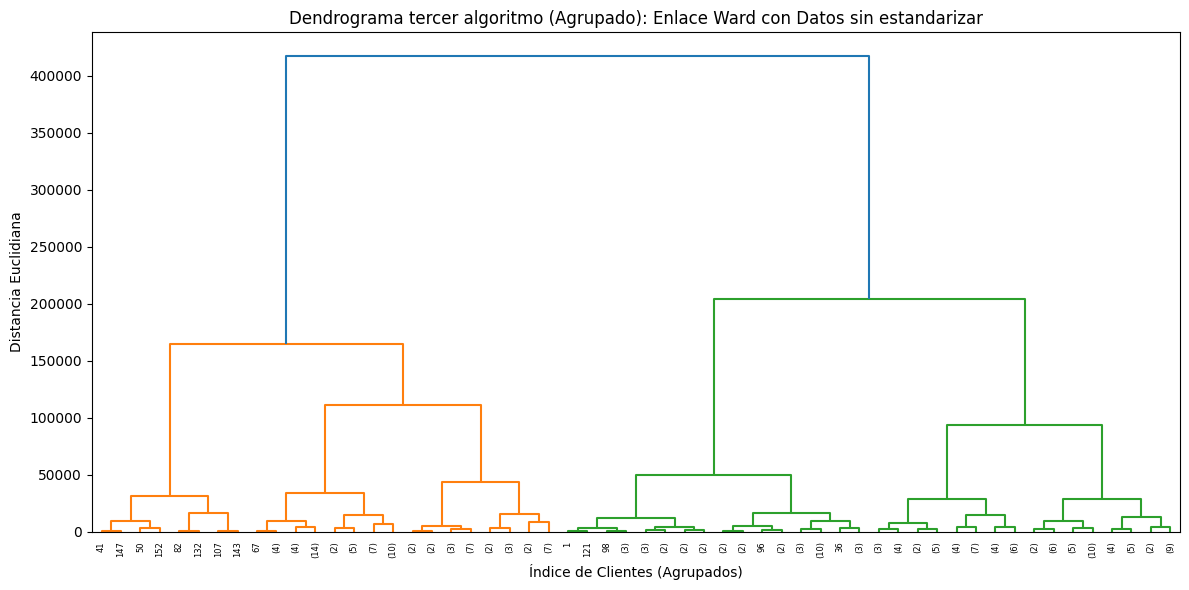

In [ ]:
# 1. Seleccionar exclusivamente las dos variables
X_original = df[['Ingreso', 'Puntaje_Gasto']]

# 2. Calculo de la matriz de distancias euclidianas
distancias_raw = pdist(X_original, metric='euclidean')

# 3. Clustering jerárquico usando el enlace de Completo
Z_ward_raw = linkage(distancias_raw, method='ward')

# 4. Graficar el dendrograma
plt.figure(figsize=(18, 7))
plt.title('Dendrograma tercer algoritmo (Sin agrupar): Enlace Ward con Datos sin estandarizar')
plt.xlabel('Índice del Cliente (Fila en el DataFrame)')
plt.ylabel('Distancia Euclidiana')

# Dendograma completo
dendrogram(Z_ward_raw,
           leaf_rotation=90.,
           leaf_font_size=8.)

plt.tight_layout()
plt.show()

# Dendograma agrupado
plt.figure(figsize=(12, 6))
plt.title('Dendrograma tercer algoritmo (Agrupado): Enlace Ward con Datos sin estandarizar')
plt.xlabel('Índice de Clientes (Agrupados)')
plt.ylabel('Distancia Euclidiana')

dendrogram(Z_ward_raw, truncate_mode='level', p=5, show_leaf_counts=True)

plt.tight_layout()
plt.show()

Ejecutando el algoritmo y visualizando el dendograma obtuvimos las siguientes conclusiones:
1. Al omitir la estandarización previa, permitimos que las escalas originales de las variables dictaran el comportamiento. Específicamente, el Ingreso (con valores en miles, llegando hasta más de 100,000) eclipsó por completo al Puntaje_Gasto (que oscila entre 1 y 99). Sobre este espacio dominado por el ingreso, el enlace de Ward calculó distancias euclidianas gobernadas casi en su totalidad por la variable de mayores magnitudes. Dado que Ward busca minimizar la varianza interna, el algoritmo terminó agrupando a los clientes basándose fundamentalmente en sus niveles de ingresos, distorsionando la verdadera multidimensionalidad del comportamiento de compra.

2. La estructura revelada por el dendrograma:
El eje vertical del gráfico representa el aumento drástico en la varianza (con una escala masiva que se dispara por encima de los 400,000 debido a la falta de escala); la información que nos muestra el dendrograma nos indica lo siguiente:

- En la parte inferior, las uniones ocurren a distancias que parecen comprimidas en la base debido al estiramiento del eje vertical, reflejando cómo la escala del ingreso domina los grupos pequeños.

- En la parte superior, las líneas verticales más largas y los saltos estructurales se extienden ininterrumpidamente hasta distancias gigantescas (cercanas a los 160,000 y 200,000, con una fusión final superior a 400,000). Esto contrasta radicalmente con el primer algoritmo (donde las distancias iban de 0 a 15): aquí, la métrica ya no refleja la sutileza de los hábitos de consumo, sino una separación basada casi exclusivamente en el poder adquisitivo.

- Si trazamos un corte horizontal en las alturas intermedias, la estructura se distorsiona artificialmente frente a los 5 clústeres limpios que encontrábamos antes. Omitir la estandarización genera un sesgo de escala donde cualquier intento de agrupación se ve secuestrado por la magnitud numérica de los ingresos.


Comparativa frente al primer algoritmo (Ward + Estandarizado):
- Esta tercer algoritmo demuestra de forma empírica la advertencia metodológica inicial. Mientras que en el primer modelo con datos estandarizados el dendrograma nos entregaba una partición equilibrada y orgánica donde el ingreso y el gasto tenían el mismo peso (mostrando distancias controladas de 0 a 15 y un óptimo claro en 5 clústeres), este modelo sin estandarizar destruye la equidad del espacio de características. Al no escalar, el algoritmo sufre de sesgo de dominancia de variable, colapsando la complejidad del cliente en una simple segmentación por ricos vs. pobres y ocultando los nichos de comportamiento real.

- Evaluar este modelo sin estandarizar ratifica por qué la preparación de los datos es un paso critico. Forzar o interpretar los clústeres de un modelo no estandarizado habría llevado a una pésima asignación de recursos comerciales, ya que la geometria del mercado era en realidad una ilusión matemática provocada por la diferencia de unidades entre las columnas. Por lo tanto, la validez de los segmentos sólo se garantiza cuando se neutralizan los sesgos de escala, reafirmando que las decisiones estratégicas de financiación deben apoyarse en modelos equilibrados.

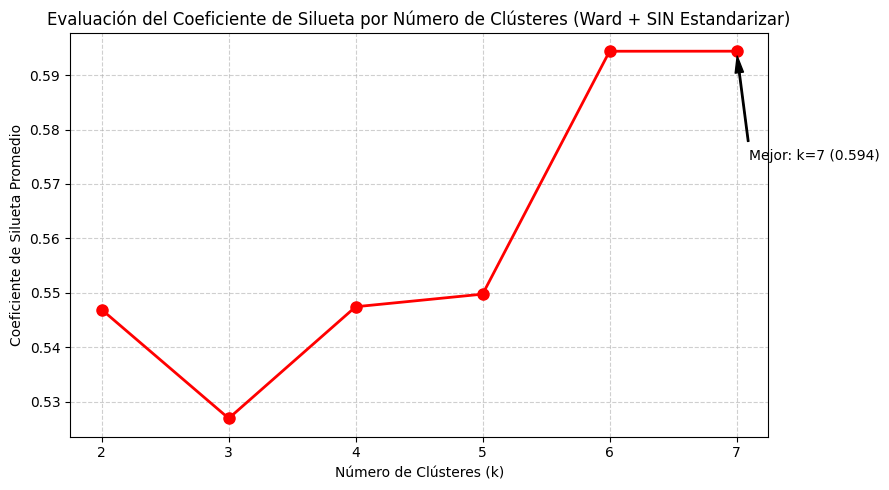

In [ ]:
# 1. Definir el rango de clústeres a evaluar
rango_clusters = range(2, 8)
valores_silueta = []

for k in rango_clusters:
    labels = fcluster(Z_ward_raw, t=k, criterion='maxclust')
    score = silhouette_score(X_original, labels)
    valores_silueta.append(score)

# 2. Graficar los resultados
plt.figure(figsize=(9, 5))
plt.plot(rango_clusters, valores_silueta, marker='o', linestyle='-', color='r', linewidth=2, markersize=8)
plt.title('Evaluación del Coeficiente de Silueta por Número de Clústeres (Ward + SIN Estandarizar)')
plt.xlabel('Número de Clústeres (k)')
plt.ylabel('Coeficiente de Silueta Promedio')
plt.grid(True, linestyle='--', alpha=0.6)

max_silueta = max(valores_silueta)
mejor_k = rango_clusters[valores_silueta.index(max_silueta)]
plt.annotate(f'Mejor: k={mejor_k} ({max_silueta:.3f})',
             xy=(mejor_k, max_silueta),
             xytext=(mejor_k + 0.1, max_silueta - 0.02),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))

plt.tight_layout()
plt.show()

La evaluación del coeficiente de silueta para el modelo sin estandarizar revela un falso óptimo en $k = 7$ con un puntaje inflado superior a $0.59$, el cual es una consecuencia directa del sesgo de escala donde la variable de ingresos domina por completo la distancia euclidiana. Aunque la métrica muestra una alta separación numérica, esta refleja únicamente una estratificación artificial por nivel de riqueza y oculta por completo la multidimensionalidad del comportamiento de compra. Este resultado demuestra que una puntuación cuantitativa elevada no valida un modelo mal preparado, ratificando de manera concluyente que la estandarización previa es un paso innegociable para evitar ilusiones métricas y garantizar que la estrategia comercial repose sobre patrones de consumo reales y equilibrados.

### 2.4 Comparativa de algoritmos y conclusiones finales del paso 2

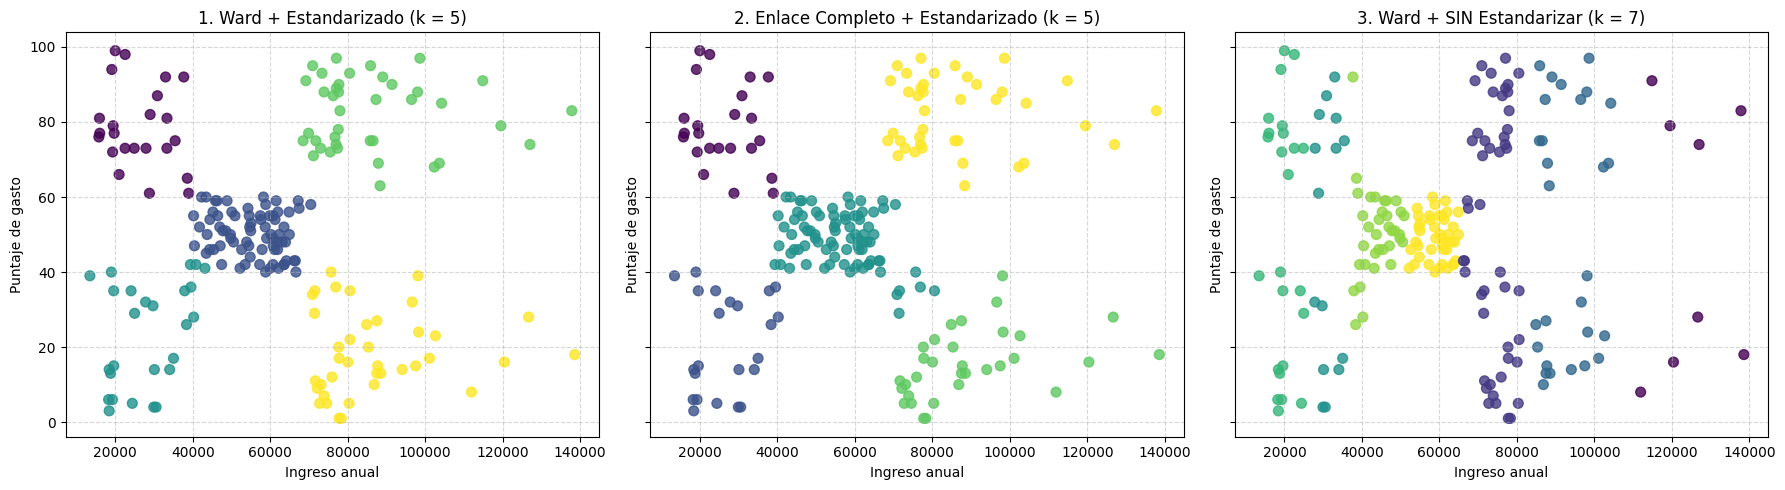

In [ ]:
# 1. Obtener las etiquetas de los tres modelos con sus respectivos K óptimos
labels_ward_scaled = fcluster(Z_ward_scaled, t=5, criterion='maxclust')
labels_complete_scaled = fcluster(Z_complete_scaled, t=5, criterion='maxclust')
labels_ward_raw = fcluster(Z_ward_raw, t=7, criterion='maxclust')

# 2. Configurar una figura con 3 subgráficas (una al lado de la otra)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

# --- Gráfica 1: Ward + Estandarizado (k=5) ---
scatter1 = axes[0].scatter(X_original['Ingreso'], X_original['Puntaje_Gasto'], c=labels_ward_scaled, cmap='viridis', s=50, alpha=0.8)
axes[0].set_title('1. Ward + Estandarizado (k = 5)')
axes[0].set_xlabel('Ingreso anual')
axes[0].set_ylabel('Puntaje de gasto')
axes[0].grid(True, linestyle='--', alpha=0.5)

# --- Gráfica 2: Enlace Completo + Estandarizado (k=5) ---
scatter2 = axes[1].scatter(X_original['Ingreso'], X_original['Puntaje_Gasto'], c=labels_complete_scaled, cmap='viridis', s=50, alpha=0.8)
axes[1].set_title('2. Enlace Completo + Estandarizado (k = 5)')
axes[1].set_ylabel('Puntaje de gasto')
axes[1].set_xlabel('Ingreso anual')
axes[1].grid(True, linestyle='--', alpha=0.5)

# --- Gráfica 3: Ward + Sin Estandarizar (k=7) ---
scatter3 = axes[2].scatter(X_original['Ingreso'], X_original['Puntaje_Gasto'], c=labels_ward_raw, cmap='viridis', s=50, alpha=0.8)
axes[2].set_title('3. Ward + SIN Estandarizar (k = 7)')
axes[2].set_ylabel('Puntaje de gasto')
axes[2].set_xlabel('Ingreso anual')
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Conclusiones:
1. Validación de los Modelos Estandarizados (Modelos 1 y 2: Ward y Enlace Completo, $k = 5$)
- Consistencia multivariada: Ambas gráficas muestran una distribución idéntica y sumamente coherente de los clústeres. El espacio de datos se divide de manera orgánica cruzando el Ingreso anual y el Puntaje de gasto.
- Segmentos comerciales claros: Se logran identificar con nitidez los grupos clave (por ejemplo, clientes de ingresos bajos con gastos bajos/altos, el grupo central moderado, y los clientes de altos ingresos divididos adecuadamente por sus hábitos de consumo). Esto confirma que ambos algoritmos respetan la multidimensionalidad del comportamiento del consumidor cuando el terreno está equilibrado.
2. El Engaño Visual del Modelo sin Estandarizar (Modelo 3: Ward + Sin Estandarizar, $k = 7$)
- Sesgo de escala en acción: La tercera gráfica expone de manera cruda el peligro de no estandarizar. Al estar dominada la distancia euclidiana por la magnitud de los ingresos, los clústeres se cortan en franjas o cortes verticales rígidos.
- Pérdida de comportamiento real: El algoritmo ignoró por completo el Puntaje de gasto en el eje vertical y se limitó a segmentar en 7 pedazos arbitrarios. Esto demuestra por qué la métrica alta de silueta en este modelo era solo una ilusión matemática: estaba agrupando por poder adquisitivo y destruyendo por completo la verdadera estructura de nichos de mercado.
3. Conclusión Estratégica Definitiva:
 La preparación de datos no es negociable: La comparativa demuestra que confiar en un modelo sin escalar habría llevado a una pésima asignación de presupuestos comerciales, segmentando a ciegas por riqueza en lugar de por comportamiento de compra real.
4. Decisión final: Gracias a la convergencia analítica entre el enlace de Ward y el enlace completo sobre datos estandarizados, queda plenamente demostrado matematicamente que el mercado se divide de forma natural en 5 nichos sólidos. Con esta certeza matemática libre de sesgos algorítmicos, la selección final de la empresa de identificar unicamente dos segmentos prioritarios a financiar deja de ser una incógnita analítica y se consolida como una decisión estrictamente estratégica y fundamentada.

# Paso 3. DBSCAN

### 3.1 Configuración 4: DBSCAN sobre Ingreso y Puntaje_Gasto estandarizados

Reutilizamos `X_scaled` del Paso 2 (Ingreso y Puntaje_Gasto estandarizados). DBSCAN necesita dos hiperparámetros: `eps` (radio de vecindad) y `min_samples` (número mínimo de vecinos para considerar un punto como núcleo denso). Para `min_samples` usamos la heurística estándar de 2×dimensiones (Sander et al.), es decir 4, ya que trabajamos en un espacio de 2 variables. Para `eps` construimos el gráfico de distancia-k, que ordena la distancia de cada punto a su 4º vecino más cercano: el punto donde esa curva se dispara (el "codo") es una buena referencia de a partir de qué distancia un punto deja de estar en una zona densa.

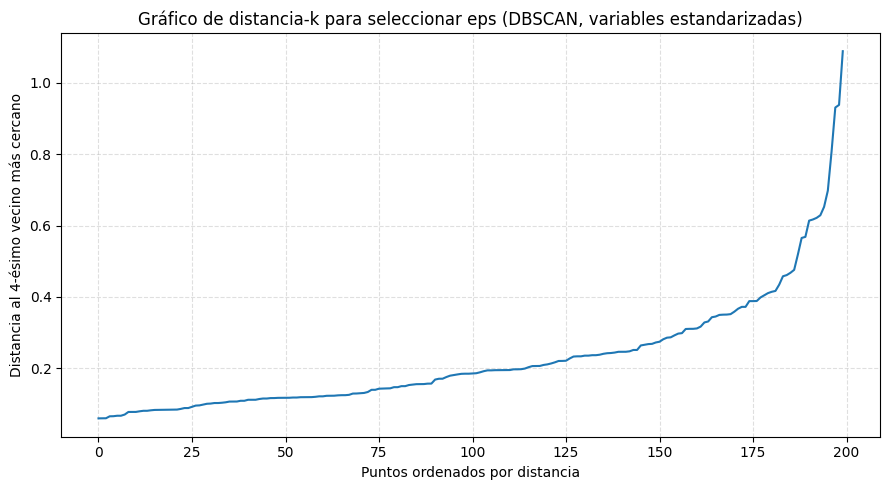

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import adjusted_rand_score

# min_samples = 2 * dimensiones (heurística estándar para datos de baja dimensión)
min_samples = 4

neigh = NearestNeighbors(n_neighbors=min_samples)
nbrs = neigh.fit(X_scaled)
distancias, _ = nbrs.kneighbors(X_scaled)
k_distancias = np.sort(distancias[:, -1])

plt.figure(figsize=(9, 5))
plt.plot(k_distancias)
plt.xlabel('Puntos ordenados por distancia')
plt.ylabel(f'Distancia al {min_samples}-ésimo vecino más cercano')
plt.title('Gráfico de distancia-k para seleccionar eps (DBSCAN, variables estandarizadas)')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

El codo de la curva aparece entre 0.30 y 0.40: antes de ese punto los puntos tienen vecinos muy cercanos (zonas densas); después, la distancia al vecino crece rápido, señal de zonas cada vez más dispersas. Ese es el rango donde conviene buscar `eps`.

### 3.2 Barrido de eps: de la sobre-fragmentación al colapso total

In [ ]:
print("Barrido de eps (min_samples=4):")
for eps in [0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.60, 0.80, 1.0]:
    db = DBSCAN(eps=eps, min_samples=min_samples).fit(X_scaled)
    etiquetas = db.labels_
    n_clusters = len(set(etiquetas)) - (1 if -1 in etiquetas else 0)
    n_ruido = (etiquetas == -1).sum()
    pct_ruido = n_ruido / len(etiquetas) * 100
    if n_clusters >= 2 and n_ruido < len(etiquetas):
        sil = silhouette_score(X_scaled[etiquetas != -1], etiquetas[etiquetas != -1])
        sil_txt = f"{sil:.4f}"
    else:
        sil_txt = "N/A"
    print(f"  eps={eps:.2f}: clusters={n_clusters}, ruido={n_ruido} ({pct_ruido:.1f}%), silueta(sin ruido)={sil_txt}")

Barrido de eps (min_samples=4):
  eps=0.15: clusters=5, ruido=100 (50.0%), silueta(sin ruido)=0.6176
  eps=0.20: clusters=8, ruido=67 (33.5%), silueta(sin ruido)=0.5952
  eps=0.25: clusters=9, ruido=38 (19.0%), silueta(sin ruido)=0.4243
  eps=0.30: clusters=7, ruido=22 (11.0%), silueta(sin ruido)=0.4829
  eps=0.35: clusters=5, ruido=19 (9.5%), silueta(sin ruido)=0.5442
  eps=0.40: clusters=2, ruido=13 (6.5%), silueta(sin ruido)=0.3939
  eps=0.45: clusters=2, ruido=13 (6.5%), silueta(sin ruido)=0.3939
  eps=0.50: clusters=1, ruido=9 (4.5%), silueta(sin ruido)=N/A
  eps=0.60: clusters=1, ruido=6 (3.0%), silueta(sin ruido)=N/A
  eps=0.80: clusters=1, ruido=0 (0.0%), silueta(sin ruido)=N/A
  eps=1.00: clusters=1, ruido=0 (0.0%), silueta(sin ruido)=N/A


Con `eps` muy bajo (0.15), la mitad de la base queda marcada como ruido: el algoritmo es demasiado exigente y descarta puntos que en realidad pertenecen a un grupo, solo porque no tienen 4 vecinos dentro de un radio tan pequeño. En el otro extremo, a partir de `eps=0.80` todo colapsa en un solo clúster: el radio es tan amplio que ya no distingue ninguna frontera entre grupos. El punto de equilibrio, donde el número de clústeres coincide con el hallado en el Paso 2 y el ruido queda en un nivel razonable, está en `eps=0.35`.

### 3.3 Los tres escenarios: exigente, elegido y laxo

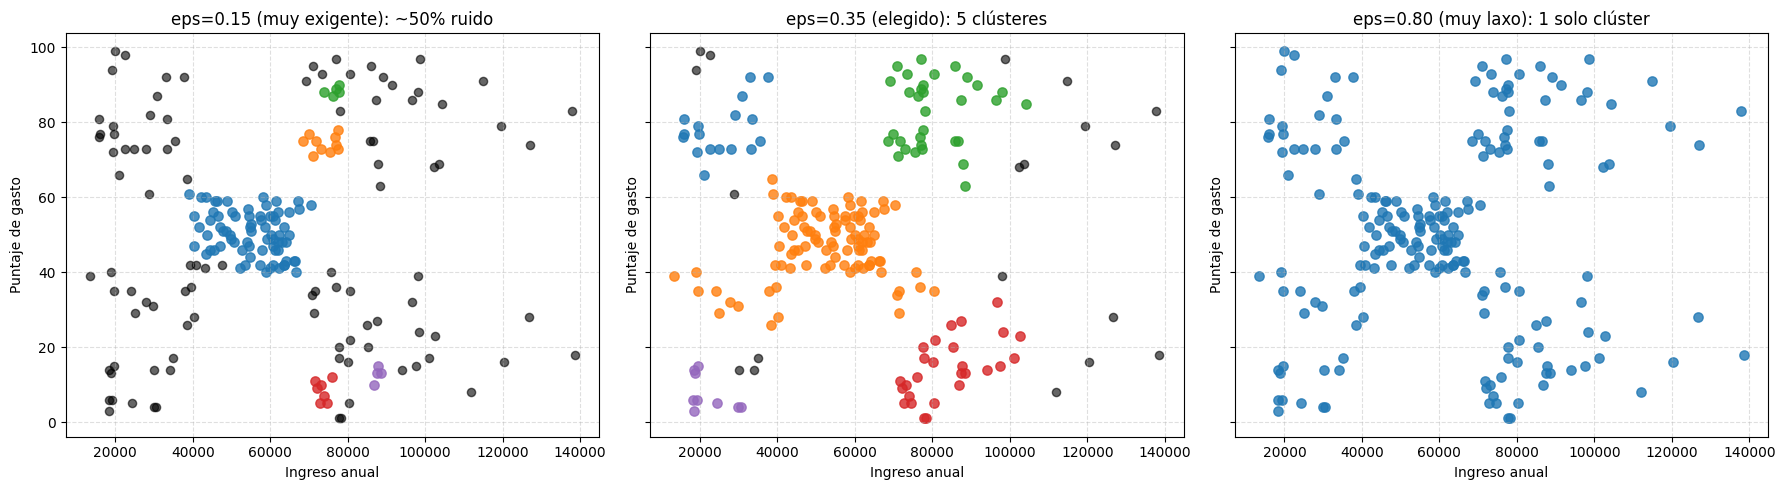

Configuración elegida -> eps=0.35, min_samples=4
Clústeres: 5 | Ruido: 19 (9.5%)


In [ ]:
configuraciones = [
    (0.15, 4, "eps=0.15 (muy exigente): ~50% ruido"),
    (0.35, 4, "eps=0.35 (elegido): 5 clústeres"),
    (0.80, 4, "eps=0.80 (muy laxo): 1 solo clúster"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)
for ax, (eps, ms, titulo) in zip(axes, configuraciones):
    db = DBSCAN(eps=eps, min_samples=ms).fit(X_scaled)
    etq = db.labels_
    for k in np.unique(etq):
        mask = etq == k
        if k == -1:
            ax.scatter(X_original.values[mask, 0], X_original.values[mask, 1],
                       c='black', s=35, alpha=0.6, label='Ruido')
        else:
            ax.scatter(X_original.values[mask, 0], X_original.values[mask, 1], s=45, alpha=0.8)
    ax.set_title(titulo)
    ax.set_xlabel('Ingreso anual')
    ax.set_ylabel('Puntaje de gasto')
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# Configuración elegida: la usamos para el resto del análisis
db_scaled = DBSCAN(eps=0.35, min_samples=4).fit(X_scaled)
labels_dbscan_scaled = db_scaled.labels_
n_clusters_dbscan = len(set(labels_dbscan_scaled)) - (1 if -1 in labels_dbscan_scaled else 0)
n_ruido_dbscan = (labels_dbscan_scaled == -1).sum()
print(f"Configuración elegida -> eps=0.35, min_samples=4")
print(f"Clústeres: {n_clusters_dbscan} | Ruido: {n_ruido_dbscan} ({n_ruido_dbscan/len(labels_dbscan_scaled)*100:.1f}%)")

**Interpretando los dos extremos — y cuál es más engañoso.**

Que una gran proporción de clientes quede como ruido (`eps=0.15`) es una falla visible: cualquiera que mire el resultado nota de inmediato que falta la mitad de los datos y sospecha del parámetro. En cambio, que **todos los clientes caigan en un solo grupo** (`eps=0.80`) es la situación **más engañosa** de las dos: un solo clúster puede leerse como "no hay estructura, no hace falta segmentar", cuando en realidad el algoritmo solo disolvió fronteras reales por exceso de tolerancia. El primer error se detecta a simple vista; el segundo puede pasar inadvertido y llevar a la conclusión de negocio equivocada.

### 3.4 Comparación cuantitativa con el clustering jerárquico (Configuración 1)

In [ ]:
ari_dbscan_ward = adjusted_rand_score(labels_ward_scaled, labels_dbscan_scaled)
print(f"Adjusted Rand Index (DBSCAN vs. Ward + Estandarizado): {ari_dbscan_ward:.3f}\n")
print("Tabla cruzada (filas = segmento Ward k=5, columnas = clúster DBSCAN, -1 = ruido):")
print(pd.crosstab(labels_ward_scaled, labels_dbscan_scaled))

Adjusted Rand Index (DBSCAN vs. Ward + Estandarizado): 0.646

Tabla cruzada (filas = segmento Ward k=5, columnas = clúster DBSCAN, -1 = ruido):
col_0  -1   0   1   2   3   4
row_0                        
1       4  17   2   0   0   0
2       0   0  74   0   0   0
3       3   0  14   0   0   9
4       7   0   0  32   0   0
5       5   0   6   0  27   0


DBSCAN, sin que se le indique cuántos grupos buscar, converge de forma independiente a **los mismos 5 grupos** que ya habíamos encontrado con Ward y con enlace completo — el Adjusted Rand Index es alto y la tabla cruzada muestra una correspondencia casi uno a uno entre segmentos. La diferencia principal es que DBSCAN, además, identifica un ~9-10% de clientes "frontera" que no encajan con claridad en ningún grupo — información que el jerárquico no ofrece, porque por construcción asigna a *todos* los clientes a algún clúster. Esta convergencia entre dos familias de algoritmos completamente distintas (uno basado en varianza, el otro en densidad) es la evidencia más sólida de que los 5 grupos **existen en los datos y no son un artefacto de un solo algoritmo**.

# Paso 4. Todas las variables (Configuración 5: DBSCAN + Distancia de Gower)

Hasta aquí trabajamos únicamente con Ingreso y Puntaje_Gasto. La base también tiene Género y Grupo_Etario, ambas categóricas. Para incorporarlas junto con las variables numéricas en un mismo clustering necesitamos una métrica de distancia que combine tipos de variable distintos — la distancia euclidiana no está definida entre categorías. Usamos la **distancia de Gower**, que calcula una disimilitud por variable (para numéricas, la diferencia normalizada por el rango; para categóricas, 0 si coinciden y 1 si no) y promedia esas disimilitudes entre todas las variables.

### 4.1 Construcción de la matriz de distancias de Gower

In [ ]:
import gower

# Seleccionamos las 4 variables: 2 numéricas + 2 categóricas
X_mixto = df[['Ingreso', 'Puntaje_Gasto', 'Genero', 'Grupo_Etario']].copy()
# Se fuerza dtype=object porque versiones recientes de pandas usan un dtype de texto
# propio que la librería gower no reconoce como categórico
X_mixto['Genero'] = X_mixto['Genero'].astype(object)
X_mixto['Grupo_Etario'] = X_mixto['Grupo_Etario'].astype(str).astype(object)

matriz_gower = gower.gower_matrix(X_mixto)
print("Forma de la matriz de distancias:", matriz_gower.shape)
print(f"Rango de distancias: [{matriz_gower.min():.3f}, {matriz_gower.max():.3f}]")

Forma de la matriz de distancias: (200, 200)
Rango de distancias: [0.000, 0.944]


### 4.2 Selección de eps sobre la distancia de Gower

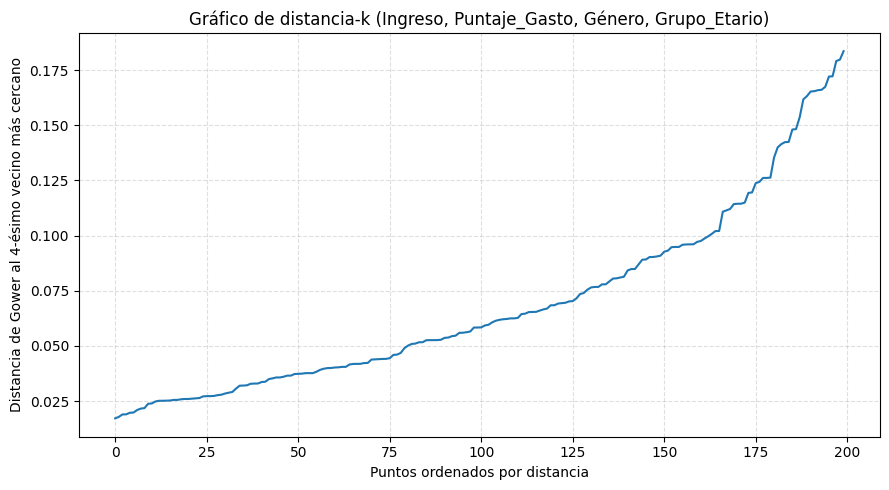

In [ ]:
k = 4
dist_ordenadas = np.sort(matriz_gower, axis=1)[:, 1:k+1]  # excluye la distancia a si mismo (columna 0)
k_dist_gower = np.sort(dist_ordenadas[:, -1])

plt.figure(figsize=(9, 5))
plt.plot(k_dist_gower)
plt.xlabel('Puntos ordenados por distancia')
plt.ylabel(f'Distancia de Gower al {k}-ésimo vecino más cercano')
plt.title('Gráfico de distancia-k (Ingreso, Puntaje_Gasto, Género, Grupo_Etario)')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
print("Barrido de eps sobre distancia de Gower (min_samples=4):")
for eps in [0.05, 0.08, 0.10, 0.12, 0.14, 0.16, 0.18, 0.20, 0.25, 0.30]:
    db = DBSCAN(eps=eps, min_samples=4, metric='precomputed').fit(matriz_gower)
    etq = db.labels_
    n_clusters = len(set(etq)) - (1 if -1 in etq else 0)
    n_ruido = (etq == -1).sum()
    if n_clusters >= 2 and n_ruido < len(etq):
        sil = silhouette_score(matriz_gower, etq, metric='precomputed')
        sil_txt = f"{sil:.4f}"
    else:
        sil_txt = "N/A"
    print(f"  eps={eps:.2f}: clusters={n_clusters}, ruido={n_ruido} ({n_ruido/len(etq)*100:.1f}%), silueta={sil_txt}")

# Configuración elegida: primer eps donde el ruido cae a un nivel bajo sin colapsar en 1 clúster
db_gower = DBSCAN(eps=0.14, min_samples=4, metric='precomputed').fit(matriz_gower)
labels_dbscan_gower = db_gower.labels_
n_clusters_gower = len(set(labels_dbscan_gower)) - (1 if -1 in labels_dbscan_gower else 0)
print(f"\nConfiguración elegida -> eps=0.14, min_samples=4")
print(f"Clústeres: {n_clusters_gower} | Ruido: {(labels_dbscan_gower==-1).sum()}")

Barrido de eps sobre distancia de Gower (min_samples=4):
  eps=0.05: clusters=20, ruido=55 (27.5%), silueta=0.3199
  eps=0.08: clusters=14, ruido=22 (11.0%), silueta=0.5207
  eps=0.10: clusters=13, ruido=13 (6.5%), silueta=0.5746
  eps=0.12: clusters=14, ruido=6 (3.0%), silueta=0.6005
  eps=0.14: clusters=12, ruido=3 (1.5%), silueta=0.6243


  eps=0.16: clusters=12, ruido=3 (1.5%), silueta=0.6243
  eps=0.18: clusters=12, ruido=0 (0.0%), silueta=0.6427
  eps=0.20: clusters=12, ruido=0 (0.0%), silueta=0.6427
  eps=0.25: clusters=12, ruido=0 (0.0%), silueta=0.6427


  eps=0.30: clusters=1, ruido=0 (0.0%), silueta=N/A

Configuración elegida -> eps=0.14, min_samples=4
Clústeres: 12 | Ruido: 3


### 4.3 ¿Qué pasó con el segmento económico original?

In [ ]:
print("Tabla cruzada: segmento económico (Ward k=5, filas) vs. clúster con Gower (columnas, -1=ruido)")
print(pd.crosstab(labels_ward_scaled, labels_dbscan_gower))

Tabla cruzada: segmento económico (Ward k=5, filas) vs. clúster con Gower (columnas, -1=ruido)
col_0  -1    0    1    2    3    4    5    6    7    8    9    10   11
row_0                                                                 
1        2    0    9    0    0    3    3    5    0    1    0    0    0
2        0    5    8    4    4    7    4    7    8    2    6   15    4
3        1    5    0    1    2    3    0    1    1    2    4    5    1
4        0    6    0    0    0   15   11    0    0    7    0    0    0
5        0    6    1    0    3    4    4    3    0    6    4    5    2


**El resultado salta de 5 clústeres a 12-14**, con una silueta incluso más alta que en las configuraciones anteriores. Pero la tabla cruzada muestra que esos 12-14 grupos no son una estructura nueva: son, en su gran mayoría, **fragmentos de los mismos 5 segmentos económicos**, subdivididos por género y grupo etario.

Esto ocurre porque en la distancia de Gower **cada variable pesa lo mismo**, sin importar cuánta información aporte: con 2 variables numéricas y 2 categóricas, las categóricas terminan representando la mitad del peso total de la distancia — a pesar de que el Paso 1 ya había mostrado que el género **no** distingue el comportamiento de compra (Mann-Whitney, p=0.461 y p=0.571). Una silueta más alta aquí no indica una segmentación mejor: indica que el algoritmo está separando por combinaciones demográficas, no por comportamiento.

**¿Deberíamos entonces segmentar por género, ya que técnicamente se puede?** No. Incluirlo no le da más foco a la campaña: cambia la pregunta sin avisar, de "¿quién gasta distinto?" a "¿quién es demográficamente distinto?". El costo de dirigir una campaña por género sin que la variable distinga comportamiento de compra es concreto: se dividiría el presupuesto entre grupos que, en la práctica, compran igual — dinero de marketing gastado en una diferencia que no existe.

# Paso 5. Ranking y recomendación

### 5.1 Ranking de configuraciones

In [ ]:
ranking_configs = pd.DataFrame([
    {"configuración": "1. Ward + Estandarizado",     "silueta": 0.550, "estabilidad": "Alta (ARI=0.87 vs. Completo; ARI=0.65 vs. DBSCAN)", "interpretabilidad": "Alta: 5 grupos accionables"},
    {"configuración": "2. Completo + Estandarizado",  "silueta": 0.550, "estabilidad": "Alta (converge con Ward)",                            "interpretabilidad": "Alta: misma partición que Ward"},
    {"configuración": "3. Ward + Sin estandarizar",   "silueta": 0.594, "estabilidad": "Baja (óptimo distinto, k=7, dominado por escala)",    "interpretabilidad": "Baja: corta solo por nivel de ingreso"},
    {"configuración": "4. DBSCAN + Estandarizado",    "silueta": 0.544, "estabilidad": "Media (sensible a eps; confirma Ward)",               "interpretabilidad": "Alta: confirma los 5 grupos y aísla la frontera"},
    {"configuración": "5. DBSCAN + Gower (4 var.)",   "silueta": 0.649, "estabilidad": "Baja (12-14 grupos muy pequeños)",                    "interpretabilidad": "Baja: fragmenta sin nueva señal de negocio"},
])
ranking_configs

,configuración,silueta,estabilidad,interpretabilidad
0,1. Ward + Estandarizado,0.550,Alta (ARI=0.87 vs. Completo; ARI=0.65 vs. DBSCAN),Alta: 5 grupos accionables
1,2. Completo + Estandarizado,0.550,Alta (converge con Ward),Alta: misma partición que Ward
2,3. Ward + Sin estandarizar,0.594,"Baja (óptimo distinto, k=7, dominado por escala)",Baja: corta solo por nivel de ingreso
3,4. DBSCAN + Estandarizado,0.544,Media (sensible a eps; confirma Ward),Alta: confirma los 5 grupos y aísla la frontera
4,5. DBSCAN + Gower (4 var.),0.649,Baja (12-14 grupos muy pequeños),Baja: fragmenta sin nueva señal de negocio


**La silueta más alta no gana automáticamente.** Las configuraciones 3 y 5 tienen la silueta más alta de las cinco, y sin embargo son las que menos conviene recomendar. La silueta mide compacidad y separación matemática, no si esa separación tiene sentido de negocio: la 3 separa por magnitud de ingreso (sesgo de escala) y la 5 separa por combinaciones demográficas sin sustento de comportamiento (Paso 4). Las configuraciones 1, 2 y 4 son las que convergen entre sí de forma independiente — dos algoritmos de familias distintas (jerárquico y basado en densidad) llegando a la misma partición es la evidencia más fuerte de que la estructura de 5 grupos es real y no un efecto del método elegido.

**Configuración recomendada: Clustering jerárquico, enlace de Ward, sobre Ingreso y Puntaje_Gasto estandarizados, con k=5.**

### 5.2 Perfil de los 5 segmentos

In [ ]:
perfil_segmentos = (
    df.assign(segmento=labels_ward_scaled)
      .groupby('segmento')
      .agg(
          n=('Id_Cliente', 'count'),
          ingreso_medio=('Ingreso', 'mean'),
          gasto_medio=('Puntaje_Gasto', 'mean'),
          edad_media=('Edad', 'mean'),
      )
      .round(1)
)
perfil_segmentos['pct_base'] = (perfil_segmentos['n'] / len(df) * 100).round(1)
# Potencial incremental: ingreso disponible que hoy no se traduce en gasto en esta tienda
perfil_segmentos['potencial_incremental'] = (
    perfil_segmentos['ingreso_medio'] * (100 - perfil_segmentos['gasto_medio']) / 1000
).round(0)

perfil_segmentos.sort_values('gasto_medio', ascending=False)

,n,ingreso_medio,gasto_medio,edad_media,pct_base,potencial_incremental
segmento,,,,,,
4,39,86537.5,82.1,32.7,19.5,1549.0
1,23,26230.4,78.6,25.5,11.5,561.0
2,74,55451.3,50.2,43.6,37.0,2761.0
3,26,28274.7,23.3,44.1,13.0,2169.0
5,38,87055.1,18.6,40.4,19.0,7086.0


| Segmento | n | % base | Ingreso medio | Gasto medio | Edad media | Perfil |
|---|---|---|---|---|---|---|
| 4 | 39 | 19.5% | \$86,538 | 82.1 | 32.7 | **Premium** — alto ingreso, alto gasto |
| 1 | 23 | 11.5% | \$26,230 | 78.6 | 25.5 | **Aspiracional** — bajo ingreso, alto gasto |
| 2 | 74 | 37.0% | \$55,451 | 50.2 | 43.6 | **Estándar** — la masa, todo moderado |
| 3 | 26 | 13.0% | \$28,275 | 23.3 | 44.1 | **Cauteloso** — bajo ingreso, bajo gasto |
| 5 | 38 | 19.0% | \$87,055 | 18.6 | 40.4 | **Oportunidad perdida** — alto ingreso, bajo gasto |

### 5.3 Ranking de segmentos por atractivo comercial

El tamaño puede ser un criterio, pero no es el mejor: el segmento más grande (Estándar, 37%) es precisamente al que el cliente ya le habla con el mensaje genérico que quiere dejar de usar. Definimos el atractivo con dos criterios explícitos y complementarios:

- **Propensión actual** (gasto medio): qué tan receptivo es el segmento *hoy* a esta tienda — indica bajo riesgo de conversión.
- **Potencial incremental** (ingreso medio × cuánto no gasta hoy): cuánto dinero disponible existe en el segmento que todavía no se traduce en compras aquí.

**Segmento 4 (Premium, 19.5%)** encabeza en propensión: ya es leal y ya es rentable — una campaña aquí es de retención y profundización, de bajo riesgo.

**Segmento 5 (Oportunidad perdida, 19.0%)** encabeza en potencial incremental: tiene tanto poder adquisitivo como el Premium, pero casi no lo gasta en esta tienda — probablemente compra en otro lado. Es el segmento con mayor ingreso disponible sin capturar.

**Recomendación de los dos segmentos a financiar: 4 (Premium) y 5 (Oportunidad perdida).** No es la combinación de mayor tamaño ni la de mayor gasto conjunto — es la combinación estratégicamente complementaria: una campaña de retención para quien ya es rentable, y una de activación para quien tiene el dinero pero no lo está gastando aquí. Juntos concentran el 38.5% de la base y la mayor parte del ingreso disponible de todos los clientes.

### 5.4 Recomendación final

**¿Debe la empresa segmentar su base de clientes mediante clustering para focalizar la campaña? Sí.**

La estructura de 5 grupos es consistente entre Ward y enlace completo (ARI=0.87) y **DBSCAN la confirma de forma independiente** sin que se le indique cuántos grupos buscar (ARI=0.65, misma cantidad de grupos). No es un artefacto de un solo algoritmo: los grupos existen en los datos.

**Procedimiento recomendado:** clustering jerárquico con enlace de Ward sobre Ingreso y Puntaje_Gasto **estandarizados**, cortado en **k=5**.

**Los dos segmentos a financiar:** Premium (mensaje de retención/fidelización) y Oportunidad perdida (mensaje de activación, orientado a capturar una mayor parte de un gasto que hoy ocurre en otro lugar).

**Consideraciones y limitaciones para la empresa:**
- **No usar género como variable de segmentación.** El Paso 1 y el Paso 4 coinciden: no hay evidencia de que distinga comportamiento de compra, y forzarlo solo fragmenta la estructura real sin agregar valor.
- **La estandarización de las variables numéricas es innegociable.** Sin ella, el "óptimo" del algoritmo (Configuración 3) es una ilusión causada por la escala del ingreso, no un hallazgo de comportamiento.
- **Este es un piloto de una sola tienda con 200 clientes.** Antes de aplicar esta segmentación a toda la cadena, conviene validar que la misma estructura de 5 grupos se sostenga en tiendas con perfiles demográficos distintos.
- **DBSCAN identificó un 9-10% de clientes "frontera"** que no encajan con claridad en ningún segmento — la empresa debería decidir explícitamente si esos clientes reciben el mensaje del segmento más cercano o quedan fuera de la focalización inicial.